# 06 · Reconocimiento de Entidades Nombradas (NER)
**Proyecto:** Salud en la esfera pública — análisis de tweets en español  
**Equivalente original:** `8_NER.ipynb`

---

### Diferencias con el paper

| Aspecto | Paper | Este notebook |
|---|---|---|
| Unidad de análisis | `texto_chunk` de fragmentos | `Texto_limpio` de tweets |
| NER sobre | Corpus completo + subcorpus ciencia | Corpus completo + subcorpus salud |
| Filtro de co-ocurrencia | Fragmentos con palabra 'ciencia*' | Tweets con palabra 'salud*' |
| Metadatos | Autor, Diario, Año | Author_Normalized, Entidad, Año |
| Grafo | Red 'ciencia' - entidades por año | Red 'salud' - entidades por año |

**Entradas:**
- `resultadosPropios/corpus_cleaned.parquet`
- `resultadosPropios/salud_tweets_final.parquet`

**Salidas:**
- `resultadosPropios/general_ner.parquet` — NER sobre corpus completo
- `resultadosPropios/salud_ner.parquet` — NER sobre subcorpus de salud
- `resultadosPropios/entidades_salud.xlsx` — tablas de frecuencias
- `resultadosPropios/fig_frecuencia_por_tipo.png`
- `resultadosPropios/fig_grafo_salud_{año}.png` — grafos por año


## 0 · Configuración

In [6]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios')

COL_AUTOR   = 'Author_Normalized'
COL_FECHA   = 'Fecha'
COL_ENTIDAD = 'Entidad'

# Modelo NER (mismo que el paper)
NER_MODEL = 'Babelscape/wikineural-multilingual-ner'

# Entidades genéricas a excluir del grafo
ENTIDADES_EXCLUIR = [
    'Colombia', 'Estado', 'Gobierno', 'Mundo', 'Nacion',
    'America Latina', 'Ciudadanos', 'Nacional', 'Personas',
    'Organizaciones', 'Ministerio', 'Salud',
]

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')
print(f'  Modelo NER     : {NER_MODEL}')


[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios
  Modelo NER     : Babelscape/wikineural-multilingual-ner


## 1 · Imports y carga de datos

In [7]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# Equivalente a celdas 0-3 del paper
# ============================================================
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import pandas as pd
import numpy as np
from collections import Counter
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import warnings
warnings.filterwarnings('ignore')

device = 0 if torch.cuda.is_available() else -1
print(f'Dispositivo NER : {"GPU" if device == 0 else "CPU"}')

# Corpus completo
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus[COL_FECHA] = pd.to_datetime(corpus[COL_FECHA], errors='coerce')
corpus['Anio'] = corpus[COL_FECHA].dt.year

# Subcorpus de salud
tweets_salud = pd.read_parquet(DATA_PROCESSED / 'salud_tweets_final.parquet')
tweets_salud.rename(columns={'fecha': 'Fecha', 'autor': COL_AUTOR}, inplace=True)
tweets_salud['Fecha'] = pd.to_datetime(tweets_salud['Fecha'], errors='coerce')

# Merge metadatos al subcorpus
tweets_salud = tweets_salud.merge(
    corpus[['id_doc', COL_AUTOR, COL_ENTIDAD, 'Anio', 'Texto_limpio']],
    on='id_doc', how='left', suffixes=('', '_corpus')
)

print(f'Corpus completo    : {len(corpus):,} tweets')
print(f'Subcorpus de salud : {len(tweets_salud):,} tweets')
corpus.head(2)


Dispositivo NER : GPU
Corpus completo    : 151,424 tweets
Subcorpus de salud : 33,982 tweets


,id_doc,Author_Normalized,Author Name,Fecha,Date,anio,mes,anio_mes,Location,Number of Likes,Number of Retweets,Hashtags,Mentions,Sentimiento,Polaridad,Entidad,Content,Texto_limpio,n_palabras,Anio
0,1,@treporta,Telemetro Reporta,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,['#panama'],[],otro,Neutra,"Noticias locales, nacionales o globales",VÍDEO| Reos que no están contagiados con COVID...,VDEO Reos que no estn contagiados con COVID19 ...,15,2020
1,2,@annytak21,ANNA KAROLYNNA,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,[],"['@ivanduque', '@jaimepumarejo']",otro,Negativa,Sin descripción,@IvanDuque @jaimepumarejo ya se enteraron de l...,ya se enteraron de la muerte supestamente por ...,24,2020


## 2 · Cargar modelo NER
Mismo modelo que el paper: `Babelscape/wikineural-multilingual-ner`.  
Reconoce PER (personas), ORG (organizaciones), LOC (lugares) y MISC.


In [8]:
# ============================================================
# CELL 2 — CARGAR MODELO NER
# Equivalente a celda 5 del paper
# ============================================================

tokenizer    = AutoTokenizer.from_pretrained(NER_MODEL)
model_ner    = AutoModelForTokenClassification.from_pretrained(NER_MODEL)
ner_pipeline = pipeline(
    'ner',
    model=model_ner,
    tokenizer=tokenizer,
    aggregation_strategy='simple',   # reemplaza grouped_entities=True (deprecated)
    device=device,
)
print(f'Modelo NER cargado: {NER_MODEL}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Babelscape/wikineural-multilingual-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo NER cargado: Babelscape/wikineural-multilingual-ner


## 3 · Función de extracción de entidades
Réplica exacta de `extraer_entidades()` del paper.  
Para tweets la longitud es corta (~25 palabras), así que el bucle de  
fragmentación raramente se activa, pero se mantiene por robustez.


In [9]:
# ============================================================
# CELL 3 — FUNCION NER
# Replica exacta de extraer_entidades() del paper (celda 6)
# ============================================================

def extraer_entidades(texto: str, max_palabras: int = 400) -> list:
    """
    Extrae entidades nombradas de un texto.
    Divide en fragmentos si supera max_palabras (limite del modelo).
    Devuelve lista de tuplas (tipo_entidad, texto_entidad).
    Replica exacta de extraer_entidades() del paper.
    """
    entidades = []
    try:
        palabras = str(texto).split()
        for i in range(0, len(palabras), max_palabras):
            fragmento  = ' '.join(palabras[i : i + max_palabras])
            resultados = ner_pipeline(fragmento)
            for r in resultados:
                tipo   = r.get('entity_group', '').strip()
                nombre = r.get('word', '').strip()
                if tipo and nombre:
                    entidades.append((tipo, nombre))
    except Exception as e:
        print(f'Error procesando texto: {e}')
    return entidades

# Prueba rapida
print(extraer_entidades('El Ministerio de Salud de Colombia anuncio nuevas medidas.'))


[('ORG', 'Ministerio de Salud de Colombia')]


## 4 · NER sobre el corpus completo
Equivalente a las celdas 9-10 del paper.  
⚠️ Este paso puede tardar varios minutos dependiendo del tamaño del corpus.


In [10]:
# ============================================================
# CELL 4 — NER CORPUS COMPLETO
# Equivalente a celdas 9-10 del paper
# ============================================================

RUTA_GENERAL_NER = DATA_PROCESSED / 'general_ner.parquet'

if RUTA_GENERAL_NER.exists():
    print(f'Archivo encontrado, cargando: {RUTA_GENERAL_NER}')
    resultado_general = pd.read_parquet(RUTA_GENERAL_NER)
else:
    print('Extrayendo entidades del corpus completo...')
    tqdm.pandas(desc='NER corpus')
    corpus['entidades'] = corpus['Texto_limpio'].progress_apply(extraer_entidades)

    resultado_general = corpus[['id_doc', COL_AUTOR, COL_FECHA, 'Anio',
                                'Texto_limpio', 'entidades']].copy()
    resultado_general.to_parquet(RUTA_GENERAL_NER, index=False)
    print(f'[GUARDADO] general_ner.parquet ({len(resultado_general):,} tweets)')

print(f'Tweets con NER: {len(resultado_general):,}')
resultado_general.head(2)


Extrayendo entidades del corpus completo (modo batch GPU)...


NER corpus GPU: 100%|██████████| 151424/151424 [00:00<00:00, 1007241.73it/s]


[GUARDADO] general_ner.parquet (151,424 tweets)
Tweets con NER: 151,424


,id_doc,Author_Normalized,Fecha,Anio,Texto_limpio,entidades
0,1,@treporta,2020-06-03,2020,VDEO Reos que no estn contagiados con COVID19 ...,"[(LOC, Santiago), (LOC, Ifarhu Panam)]"
1,2,@annytak21,2020-06-03,2020,ya se enteraron de la muerte supestamente por ...,"[(PER, Sandra Correa)]"


## 5 · NER sobre el subcorpus de salud
Equivalente a las celdas 11-13 del paper (NER sobre fragmentos de ciencia).  
Aquí lo aplicamos sobre los tweets con mención de salud.


In [11]:
# ============================================================
# CELL 5 — NER SUBCORPUS SALUD
# Equivalente a celdas 11-13 del paper
# ============================================================

RUTA_SALUD_NER = DATA_PROCESSED / 'salud_ner.parquet'

if RUTA_SALUD_NER.exists():
    print(f'Archivo encontrado, cargando: {RUTA_SALUD_NER}')
    resultado_salud = pd.read_parquet(RUTA_SALUD_NER)
else:
    print('Extrayendo entidades del subcorpus de salud...')
    tqdm.pandas(desc='NER salud')
    tweets_salud['entidades'] = tweets_salud['Texto_limpio'].progress_apply(
        extraer_entidades
    )
    resultado_salud = tweets_salud[[
        'id_doc', COL_AUTOR, 'Fecha', 'Anio',
        'categoria_detectada', 'Texto_limpio', 'entidades'
    ]].copy()
    resultado_salud.to_parquet(RUTA_SALUD_NER, index=False)
    print(f'[GUARDADO] salud_ner.parquet ({len(resultado_salud):,} tweets)')

print(f'Tweets de salud con NER: {len(resultado_salud):,}')
resultado_salud.head(2)


Extrayendo entidades del subcorpus de salud...


NER salud: 100%|██████████| 33982/33982 [06:45<00:00, 83.74it/s] 


[GUARDADO] salud_ner.parquet (33,982 tweets)
Tweets de salud con NER: 33,982


,id_doc,Author_Normalized,Fecha,Anio,categoria_detectada,Texto_limpio,entidades
0,6,@bebita11385037,2020-06-03,2020,Salud_Lucha_enfermedades,La otra semana ya saldr el aumento de contagio...,"[(MISC, Co), (LOC, Potos)]"
1,9,@jairojrsandhers,2020-06-03,2020,Salud_Materno_infantil,El expide la Directiva 012 con orientaciones a...,"[(MISC, Directiva 012)]"


## 6 · Análisis de frecuencias de entidades
Equivalente a las celdas 18-23 del paper.


In [12]:
# ============================================================
# CELL 6 — APLANAR Y CONTAR ENTIDADES
# Equivalente a celdas 18-23 del paper
# ============================================================

def aplanar_entidades(df_ner: pd.DataFrame) -> pd.DataFrame:
    """Convierte lista de tuplas por fila a un DataFrame plano."""
    todas = []
    for _, row in df_ner.iterrows():
        for tipo, nombre in row['entidades']:
            if isinstance(tipo, str) and isinstance(nombre, str):
                todas.append({
                    'id_doc': row['id_doc'],
                    'Tipo'  : tipo,
                    'Entidad': nombre.strip(),
                })
    return pd.DataFrame(todas)

# Aplanar subcorpus de salud
df_plano = aplanar_entidades(resultado_salud)
print(f'Entidades extraidas (salud): {len(df_plano):,}')
print(f'Tipos encontrados          : {df_plano["Tipo"].unique()}')

# Frecuencia por tipo
freq_tipo = (
    df_plano.groupby('Tipo').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)
print()
print(freq_tipo.to_string(index=False))


Entidades extraidas (salud): 68,599
Tipos encontrados          : <ArrowStringArray>
['MISC', 'LOC', 'ORG', 'PER']
Length: 4, dtype: str

Tipo  Frecuencia
 LOC       31552
MISC       23413
 ORG        8812
 PER        4822


## 7 · Gráfico de frecuencia por tipo de entidad

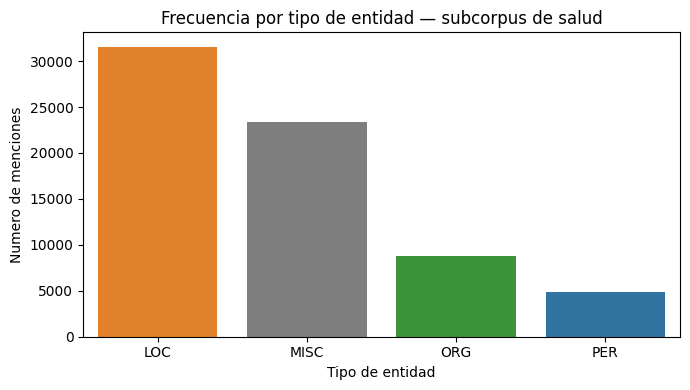

[GUARDADO] fig_frecuencia_por_tipo.png


In [13]:
# ============================================================
# CELL 7 — GRAFICO POR TIPO
# Replica de celda 21 del paper
# ============================================================

palette = {'PER': '#1f77b4', 'ORG': '#2ca02c', 'LOC': '#ff7f0e', 'MISC': '#7f7f7f'}

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=freq_tipo, x='Tipo', y='Frecuencia',
            palette=[palette.get(t, '#999') for t in freq_tipo['Tipo']], ax=ax)
ax.set_title('Frecuencia por tipo de entidad — subcorpus de salud')
ax.set_ylabel('Numero de menciones')
ax.set_xlabel('Tipo de entidad')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_frecuencia_por_tipo.png', dpi=300)
plt.show()
print('[GUARDADO] fig_frecuencia_por_tipo.png')


## 8 · Top entidades por tipo
Equivalente a las celdas 22-23 del paper.



Top 10 — LOC:
 Entidad  Frecuencia
   China        2696
Colombia        2461
  Madrid         873
Andaluca         456
   Bogot         444
    Cuba         369
   Wuhan         347
  Crdoba         312
  Brasil         261
    EEUU         232

Top 10 — MISC:
    Entidad  Frecuencia
         Co        2423
    Covid19        1796
    COVID19        1525
      Covid         958
         CO         796
Coronavirus         556
     Corona         542
      COVID         477
         co         230
     ##date         203

Top 10 — ORG:
            Entidad  Frecuencia
                OMS         529
                UCI         369
                 Co         300
Ministerio de Salud         194
              Covid         128
            Covid19         101
              Mxico          71
 Secretara de Salud          65
                 EU          61
              Salud          61

Top 10 — PER:
        Entidad  Frecuencia
          Trump          73
 Francisco Durn          47
        

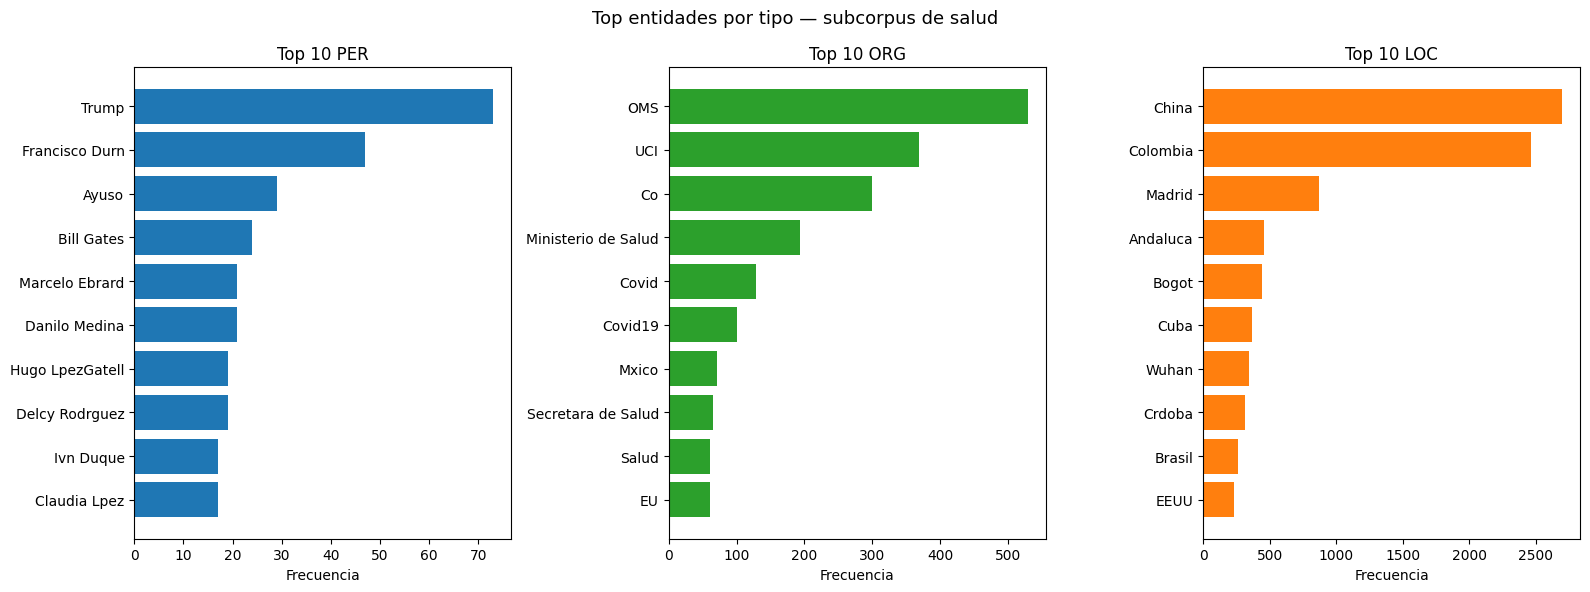

[GUARDADO] fig_top_entidades_por_tipo.png


In [14]:
# ============================================================
# CELL 8 — TOP ENTIDADES POR TIPO
# Equivalente a celdas 22-23 del paper
# ============================================================

top_por_tipo = (
    df_plano.groupby(['Tipo', 'Entidad']).size()
    .reset_index(name='Frecuencia')
    .sort_values(['Tipo', 'Frecuencia'], ascending=[True, False])
)
top10 = top_por_tipo.groupby('Tipo').head(10)

for tipo in top10['Tipo'].unique():
    subset = top10[top10['Tipo'] == tipo]
    print(f'\nTop 10 — {tipo}:')
    print(subset[['Entidad', 'Frecuencia']].to_string(index=False))

# Grafico por tipo
tipos_principales = ['PER', 'ORG', 'LOC']
fig, axes = plt.subplots(1, len(tipos_principales), figsize=(16, 6))

for ax, tipo in zip(axes, tipos_principales):
    subset = top_por_tipo[top_por_tipo['Tipo'] == tipo].head(10)
    if subset.empty:
        ax.set_visible(False)
        continue
    subset = subset.sort_values('Frecuencia', ascending=True)
    ax.barh(subset['Entidad'], subset['Frecuencia'],
            color=palette.get(tipo, '#999'))
    ax.set_title(f'Top 10 {tipo}')
    ax.set_xlabel('Frecuencia')

plt.suptitle('Top entidades por tipo — subcorpus de salud', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_entidades_por_tipo.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_entidades_por_tipo.png')


## 9 · Entidades co-ocurrentes con 'salud'
Equivalente a las celdas 28-31 del paper (co-ocurrencias con 'ciencia*').  
Filtramos tweets que contienen la palabra 'salud' y extraemos  
las entidades PER/ORG que aparecen junto a ella.


In [15]:
# ============================================================
# CELL 9 — COOCURRENCIAS CON 'SALUD'
# Equivalente a celdas 28-31 del paper
# ============================================================

# Filtrar tweets que contienen 'salud*'
mask_salud = resultado_salud['Texto_limpio'].str.contains(
    r'\bsalud\w*', flags=re.IGNORECASE, na=False
)
df_con_salud = resultado_salud[mask_salud].copy()
print(f'Tweets con palabra salud* : {len(df_con_salud):,}')

def obtener_entidades_org_per(entidades: list) -> list:
    """Filtra solo entidades PER y ORG. Replica del paper."""
    if not entidades:
        return []
    return [
        (e[0], e[1]) for e in entidades
        if len(e) == 2 and e[0] in ('ORG', 'PER') and isinstance(e[1], str)
    ]

# Construir pares (anio, 'salud', tipo, entidad)
pares = []
for _, fila in df_con_salud.iterrows():
    anio = fila.get('Anio')
    if pd.isna(anio):
        continue
    for tipo, entidad in obtener_entidades_org_per(fila['entidades']):
        if entidad.strip() in ENTIDADES_EXCLUIR:
            continue
        pares.append((int(anio), 'salud', tipo, entidad.strip()))

df_pares = pd.DataFrame(pares, columns=['Anio', 'Palabra', 'Tipo', 'Entidad'])

freq_cooc = (
    df_pares.groupby(['Anio', 'Tipo', 'Entidad']).size()
    .reset_index(name='frecuencia')
    .sort_values(['Anio', 'frecuencia'], ascending=[True, False])
)
print(f'Entidades co-ocurrentes con salud: {len(freq_cooc):,}')
print(freq_cooc.head(10).to_string(index=False))


Tweets con palabra salud* : 4,061
Entidades co-ocurrentes con salud: 1,576
 Anio Tipo                             Entidad  frecuencia
 2020  ORG                 Ministerio de Salud         194
 2020  ORG                  Secretara de Salud          65
 2020  ORG         Instituto Nacional de Salud          60
 2020  ORG                                 OMS          54
 2020  ORG                                  Co          41
 2020  ORG                                 UCI          39
 2020  ORG Organizacin Mundial de la Salud OMS          38
 2020  ORG     Organizacin Mundial de la Salud          36
 2020  ORG          Ministerio de Salud Pblica          32
 2020  ORG                        Salud Pblica          26


## 10 · Top entidades asociadas a 'salud' por año
Equivalente a la celda 31 del paper.


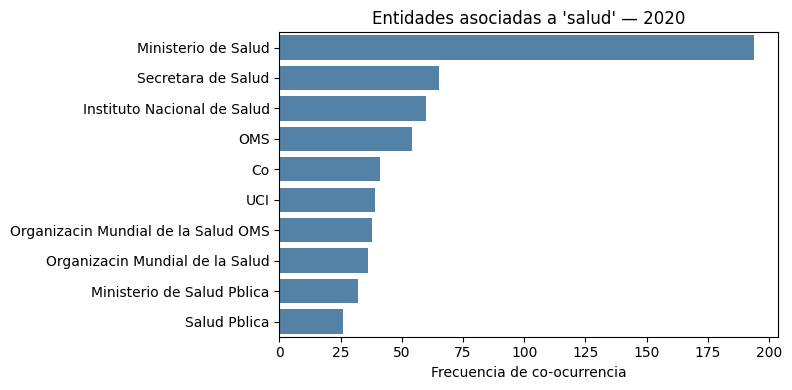

[GUARDADO] fig_coocurrencias_salud_2020.png


In [16]:
# ============================================================
# CELL 10 — BARRAS POR ANO
# Equivalente a celda 31 del paper
# ============================================================

anios = sorted(freq_cooc['Anio'].dropna().unique())

for anio in anios:
    top = freq_cooc[freq_cooc['Anio'] == anio].head(10)
    if top.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=top, y='Entidad', x='frecuencia', color='steelblue', ax=ax)
    ax.set_title(f"Entidades asociadas a 'salud' — {anio}")
    ax.set_xlabel('Frecuencia de co-ocurrencia')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(DATA_PROCESSED / f'fig_coocurrencias_salud_{anio}.png', dpi=300)
    plt.show()
    print(f'[GUARDADO] fig_coocurrencias_salud_{anio}.png')


## 11 · Grafo de red: 'salud' — entidades
Equivalente a la celda 32 del paper.  
Red donde el nodo central es 'salud' y los nodos periféricos son  
las entidades PER/ORG que co-ocurren con él, por año.


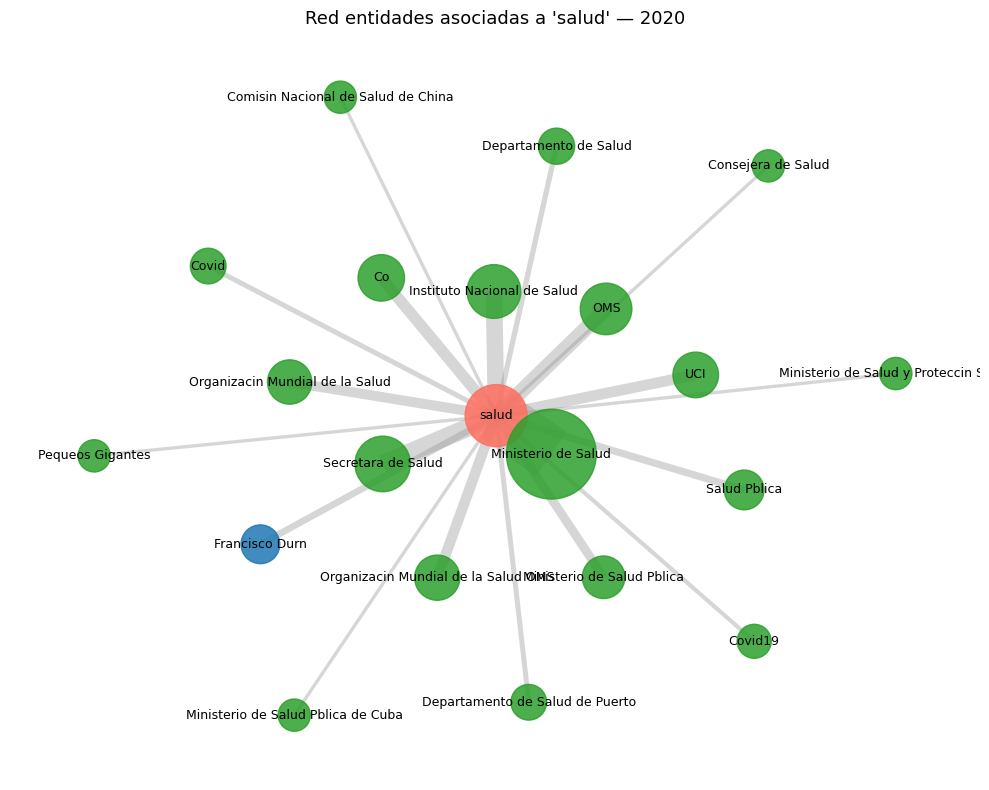

[GUARDADO] fig_grafo_salud_2020.png


In [17]:
# ============================================================
# CELL 11 — GRAFO DE RED
# Equivalente a celda 32 del paper (mismos colores y logica)
# ============================================================

for anio in anios:
    top = freq_cooc[freq_cooc['Anio'] == anio].head(20)
    if top.empty:
        continue

    G = nx.Graph()
    G.add_node('salud', size=2000, color='#FF6F61')  # rojo: nodo central

    for _, row in top.iterrows():
        entidad = row['Entidad']
        tipo    = row['Tipo']
        peso    = row['frecuencia']
        color   = '#1f77b4' if tipo == 'PER' else '#2ca02c'  # azul PER, verde ORG
        G.add_node(entidad, size=300 + peso * 20, color=color)
        G.add_edge('salud', entidad, weight=peso)

    pos = nx.spring_layout(G, k=0.7, center=(0, 0), seed=42)

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(
        G, pos, alpha=0.4,
        width=[d['weight'] * 0.2 for (_, _, d) in G.edges(data=True)],
        edge_color='#999999'
    )
    nx.draw_networkx_nodes(
        G, pos,
        node_color=[G.nodes[n]['color'] for n in G.nodes()],
        node_size=[G.nodes[n]['size']  for n in G.nodes()],
        alpha=0.85
    )
    nx.draw_networkx_labels(G, pos, font_size=9)
    plt.title(f"Red entidades asociadas a 'salud' — {anio}", fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    ruta_grafo = DATA_PROCESSED / f'fig_grafo_salud_{anio}.png'
    plt.savefig(ruta_grafo, dpi=300)
    plt.show()
    print(f'[GUARDADO] fig_grafo_salud_{anio}.png')


## 12 · Guardar tablas

In [18]:
# ============================================================
# CELL 12 — GUARDAR TABLAS
# Equivalente a celda 24 del paper
# ============================================================

resumen = (
    df_plano.groupby(['Tipo', 'Entidad']).size()
    .reset_index(name='Frecuencia')
    .sort_values(['Tipo', 'Frecuencia'], ascending=[True, False])
)

ruta_excel = DATA_PROCESSED / 'entidades_salud.xlsx'
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    freq_tipo.to_excel(writer,    sheet_name='Frecuencia_por_tipo',  index=False)
    top10.to_excel(writer,        sheet_name='Top10_por_tipo',       index=False)
    resumen.to_excel(writer,      sheet_name='Todas_entidades',      index=False)
    freq_cooc.to_excel(writer,    sheet_name='Coocurrencias_salud',  index=False)

print(f'[GUARDADO] entidades_salud.xlsx')
print()
print('Notebook 06 completado.')
print('Siguiente -> 07_bertopic_general.ipynb')


[GUARDADO] entidades_salud.xlsx

Notebook 06 completado.
Siguiente -> 07_bertopic_general.ipynb
